## Lab Exercise 3

### Student Survey: Simple Linear Regression using Scikit Learn, OLS, and Parameter Saving

### Aim 

1. To collect real-world student survey data using Google Forms, preprocess and clean the dataset, perform
2. Simple Linear Regression using Scikit-learn, manually compute the regression equation using Ordinary
3. Least Squares (OLS) formulas, compare both approaches, and save the learned model parameters.

### Problem Statement
Using the dataset collected from the class survey form, perform Simple Linear Regression analysis to
determine whether:
1. CIA percentage can predict GPA
2. Attendance percentage can predict GPA

You are required to perform regression in two different ways:
1. Using Scikit learn Linear Regression
2. Manually using the mathematical equations of slope and intercept derived from Ordinary Least
Squares (OLS)

Finally, compare the outputs obtained from both methods and save the learned model parameters.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

### Part A: Data Collection and Preprocessing

**1. Load the dataset using Pandas**

**2. Display the first 5 rows**

In [45]:
data = pd.read_csv('Department Awareness.csv')
data.head()

,Timestamp,RegNo,Email,Job role that you are interested in\n,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),MedianSalaryOfPlacedStudents,Which is the highest paying company,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),LastSemesterCIA,your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,6-22-2026 8:49:31,2547123,jiyaelza.jabi@mca.christuniversity.in,Software Engineer,4,Option 1,9,Deolite,2,2,7,78,3.24,Option 1,Industry
1,6-22-2026 8:49:51,2547122,jinishaleema.rosario@mca.christuniversity.in,Data Engineer,"7,00,000",Option 1,"4,50,000",Deolite,4,3,"6,00,000",64.78,3.2,Option 1,Industry
2,6-22-2026 8:50:45,2547101,rajeev.chandar@mca.christuniversity.in,Software Engineer,6,17,8,DE Shaw,5,5,13,80,3.6,Option 1,Industry
3,6-22-2026 8:51:01,2547156,sounak.chakraborty@mca.christuniversity.in,Data Scientist,4.5,12,6.9,DE Shaw,3,4,7,70,3.2,92,Industry
4,6-22-2026 8:51:42,2547148,samar.subhash@mca.christuniversity.in,Software Engineer,8,12,10,EY,5,3,10,68,3.4,85,Industry


**3. Check dataset dimensions**

In [46]:
print("Shape of dataset:", data.shape)
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])

Shape of dataset: (54, 15)
Number of rows: 54
Number of columns: 15


**Since the column names are verybig and will be difficult to query, we have replaced them with shorter names.**

In [47]:
data.rename(columns={
    'Registration Number': 'RegNo',
    'Job role that you are interested in\n': 'InterestedJobRole',
    'What is the minimum salary of students placed through campus (In LPA..respond as a number)': 'MinSalaryOfPlacedStudents',
    'What is the maximum salary of students placed through campus (In LPA..respond as a number)': 'MaxSalaryOfPlacedStudents',
    'Which is the highest paying company': 'HighestPayingCompany',
    'Rate your contribution towards extra curricular activities': 'ContributionToExtraCurricularActivities',
    'Rate your technical competencies': 'TechnicalCompetencies',
    'What are your package expectations (LPA)': 'PackageExpectations',
    'your GPA of last semester': 'LastSemesterGPA',
    'Your maximum attendance % till last semester': 'MaxAttendanceTillLastSemester',
    'Internships Interests': 'InternshipInterests'
}, inplace=True)

In [48]:
data.head()

,Timestamp,RegNo,Email,InterestedJobRole,MinSalaryOfPlacedStudents,MaxSalaryOfPlacedStudents,MedianSalaryOfPlacedStudents,HighestPayingCompany,ContributionToExtraCurricularActivities,TechnicalCompetencies,PackageExpectations,LastSemesterCIA,LastSemesterGPA,MaxAttendanceTillLastSemester,InternshipInterests
0,6-22-2026 8:49:31,2547123,jiyaelza.jabi@mca.christuniversity.in,Software Engineer,4,Option 1,9,Deolite,2,2,7,78,3.24,Option 1,Industry
1,6-22-2026 8:49:51,2547122,jinishaleema.rosario@mca.christuniversity.in,Data Engineer,"7,00,000",Option 1,"4,50,000",Deolite,4,3,"6,00,000",64.78,3.2,Option 1,Industry
2,6-22-2026 8:50:45,2547101,rajeev.chandar@mca.christuniversity.in,Software Engineer,6,17,8,DE Shaw,5,5,13,80,3.6,Option 1,Industry
3,6-22-2026 8:51:01,2547156,sounak.chakraborty@mca.christuniversity.in,Data Scientist,4.5,12,6.9,DE Shaw,3,4,7,70,3.2,92,Industry
4,6-22-2026 8:51:42,2547148,samar.subhash@mca.christuniversity.in,Software Engineer,8,12,10,EY,5,3,10,68,3.4,85,Industry


Now, the column names are shorter and easy to include in the code. 

**Check data types**

In [49]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 15 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   Timestamp                                54 non-null     object
 1   RegNo                                    54 non-null     object
 2   Email                                    54 non-null     object
 3   InterestedJobRole                        54 non-null     object
 4   MinSalaryOfPlacedStudents                54 non-null     object
 5   MaxSalaryOfPlacedStudents                54 non-null     object
 6   MedianSalaryOfPlacedStudents             54 non-null     object
 7   HighestPayingCompany                     54 non-null     object
 8   ContributionToExtraCurricularActivities  54 non-null     int64 
 9   TechnicalCompetencies                    54 non-null     int64 
 10  PackageExpectations                      54 non-null     object


**6. Convert required columns into numerical datatype**

In [50]:
# convert 'Timestamp' column to datetime format
data['Timestamp'] = pd.to_datetime(data['Timestamp'])

# convert salary columns to numeric format
salary_cols = [
    'MinSalaryOfPlacedStudents',
    'MaxSalaryOfPlacedStudents',
    'MedianSalaryOfPlacedStudents',
    'PackageExpectations'
]

for col in salary_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# convert 'LastSemesterGPA' column to numeric format
data['LastSemesterCIA'] = pd.to_numeric(
    data['LastSemesterCIA'],
    errors='coerce'
)

# convert 'LastSemesterGPA' column to numeric format
data['LastSemesterGPA'] = pd.to_numeric(
    data['LastSemesterGPA'],
    errors='coerce'
)

In [51]:
# convert 'MaxAttendanceTillLastSemester' column to numeric format
import numpy as np

data['MaxAttendanceTillLastSemester'] = data['MaxAttendanceTillLastSemester'].replace('Option 1', np.nan)

data['MaxAttendanceTillLastSemester'] = (data['MaxAttendanceTillLastSemester'].str.replace('%', '', regex=False))

data['MaxAttendanceTillLastSemester'] = pd.to_numeric(data['MaxAttendanceTillLastSemester'],errors='coerce')

In [52]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 15 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Timestamp                                54 non-null     datetime64[ns]
 1   RegNo                                    54 non-null     object        
 2   Email                                    54 non-null     object        
 3   InterestedJobRole                        54 non-null     object        
 4   MinSalaryOfPlacedStudents                41 non-null     float64       
 5   MaxSalaryOfPlacedStudents                36 non-null     float64       
 6   MedianSalaryOfPlacedStudents             42 non-null     float64       
 7   HighestPayingCompany                     54 non-null     object        
 8   ContributionToExtraCurricularActivities  54 non-null     int64         
 9   TechnicalCompetencies                    54 n

**4. Identify Missing Values**

In [53]:
data.isnull().sum()

Timestamp                                   0
RegNo                                       0
Email                                       0
InterestedJobRole                           0
MinSalaryOfPlacedStudents                  13
MaxSalaryOfPlacedStudents                  18
MedianSalaryOfPlacedStudents               12
HighestPayingCompany                        0
ContributionToExtraCurricularActivities     0
TechnicalCompetencies                       0
PackageExpectations                        14
LastSemesterCIA                            10
LastSemesterGPA                             1
MaxAttendanceTillLastSemester               6
InternshipInterests                         0
dtype: int64

**5. Remove or Handle Null Values**

In [54]:
num_cols = [
    'MinSalaryOfPlacedStudents',
    'MaxSalaryOfPlacedStudents',
    'MedianSalaryOfPlacedStudents',
    'PackageExpectations',
    'LastSemesterCIA',
    'MaxAttendanceTillLastSemester',
    'LastSemesterGPA'
]

for col in num_cols:
    data[col] = data[col].fillna(data[col].median())

**7. Remove Duplicate Records if Preent**

In [55]:
print("Duplicates before:", data.duplicated().sum())

data.drop_duplicates(inplace=True)

print("Duplicates after:", data.duplicated().sum())

Duplicates before: 0
Duplicates after: 0


**8. Generate statistical summary**

In [56]:
data.describe()

,Timestamp,MinSalaryOfPlacedStudents,MaxSalaryOfPlacedStudents,MedianSalaryOfPlacedStudents,ContributionToExtraCurricularActivities,TechnicalCompetencies,PackageExpectations,LastSemesterCIA,LastSemesterGPA,MaxAttendanceTillLastSemester
count,54,5.400000e+01,5.400000e+01,5.400000e+01,54.000000,54.000000,5.400000e+01,54.000000,54.000000,54.000000
mean,2026-06-22 08:53:31.388888832,3.926361e+04,4.779052e+04,1.342659e+05,3.592593,3.407407,6.297296e+04,70.926852,5.280370,93.163519
min,2026-06-22 08:49:31,2.000000e+00,8.000000e+00,5.000000e+00,2.000000,1.000000,5.000000e+00,3.450000,2.900000,85.000000
25%,2026-06-22 08:52:20.500000,4.000000e+00,1.200000e+01,6.925000e+00,3.000000,3.000000,8.000000e+00,70.000000,3.377500,90.000000
50%,2026-06-22 08:53:30.500000,4.500000e+00,1.200000e+01,7.000000e+00,4.000000,3.000000,1.000000e+01,71.000000,3.500000,93.500000
75%,2026-06-22 08:54:18.249999872,5.000000e+00,1.200000e+01,8.000000e+00,4.000000,4.000000,1.150000e+01,78.000000,3.692500,97.000000
max,2026-06-22 08:57:57,1.500000e+06,1.300000e+06,4.500000e+06,5.000000,5.000000,1.500000e+06,89.000000,90.000000,100.000000
std,NaN,2.104421e+05,2.384331e+05,6.358626e+05,0.981307,0.835950,2.735462e+05,14.537896,11.796546,4.528431


**Outlier detection and correction**

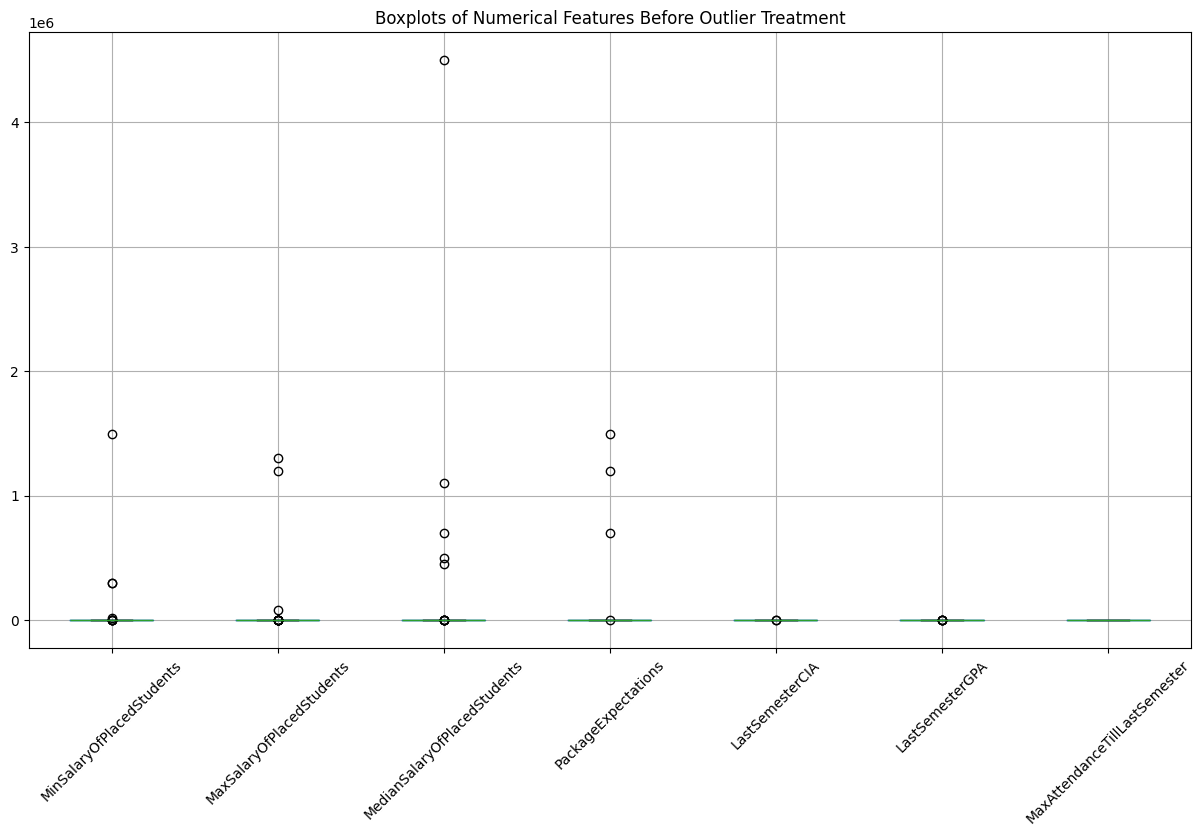

In [57]:
# plot boxplots for numerical features to visualize outliers

import matplotlib.pyplot as plt

num_cols = [
    'MinSalaryOfPlacedStudents',
    'MaxSalaryOfPlacedStudents',
    'MedianSalaryOfPlacedStudents',
    'PackageExpectations',
    'LastSemesterCIA',
    'LastSemesterGPA',
    'MaxAttendanceTillLastSemester'
]

plt.figure(figsize=(15,8))

data[num_cols].boxplot()

plt.title("Boxplots of Numerical Features Before Outlier Treatment")
plt.xticks(rotation=45)
plt.show()

In [58]:
# plot boxplots for numerical features to visualize outliers

for col in num_cols:

    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[
        (data[col] < lower) |
        (data[col] > upper)
    ]

    print(f"{col}: {len(outliers)} outliers")

MinSalaryOfPlacedStudents: 9 outliers
MaxSalaryOfPlacedStudents: 13 outliers
MedianSalaryOfPlacedStudents: 11 outliers
PackageExpectations: 4 outliers
LastSemesterCIA: 2 outliers
LastSemesterGPA: 5 outliers
MaxAttendanceTillLastSemester: 0 outliers


In [67]:
# treating outliers using Winsorization for salary columns

salary_cols = [
    'MinSalaryOfPlacedStudents',
    'MaxSalaryOfPlacedStudents',
    'MedianSalaryOfPlacedStudents',
    'PackageExpectations'
]

for col in salary_cols:

    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data[col] = data[col].clip(lower=lower, upper=upper)

print("Outliers treated using Winsorization.")

Outliers treated using Winsorization.


In [68]:
for col in salary_cols:

    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[
        (data[col] < lower) |
        (data[col] > upper)
    ]

    print(f"{col}: {len(outliers)} outliers remaining")

MinSalaryOfPlacedStudents: 0 outliers remaining
MaxSalaryOfPlacedStudents: 0 outliers remaining
MedianSalaryOfPlacedStudents: 0 outliers remaining
PackageExpectations: 0 outliers remaining


In [59]:
# for cia and gpa, we will check the range of values and observe the outliers

print("CIA Range:")
print(data['LastSemesterCIA'].min(), data['LastSemesterCIA'].max())

print()

print("GPA Range:")
print(data['LastSemesterGPA'].min(), data['LastSemesterGPA'].max())

CIA Range:
3.45 89.0

GPA Range:
2.9 90.0


In [ ]:
# treating outliers using for GPA column

data[data['LastSemesterGPA'] > 4][['RegNo', 'LastSemesterGPA']]

data = data[data['LastSemesterGPA'] <= 4]

In [73]:
# treating outliers using for CIA column

Q1 = data['LastSemesterCIA'].quantile(0.25)
Q3 = data['LastSemesterCIA'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

cia_outliers = data[
    (data['LastSemesterCIA'] < lower) |
    (data['LastSemesterCIA'] > upper)
]

cia_outliers

,Timestamp,RegNo,Email,InterestedJobRole,MinSalaryOfPlacedStudents,MaxSalaryOfPlacedStudents,MedianSalaryOfPlacedStudents,HighestPayingCompany,ContributionToExtraCurricularActivities,TechnicalCompetencies,PackageExpectations,LastSemesterCIA,LastSemesterGPA,MaxAttendanceTillLastSemester,InternshipInterests
47,2026-06-22 08:55:19,2547119,darshanpundlik.heble@mca.christuniversity.in,Software Engineer,4.5,12.0,7.0,Deolite,5,1,10.0,4.0,4.0,100.0,Industry


In [74]:
data = data[(data['LastSemesterCIA'] >= lower) &(data['LastSemesterCIA'] <= upper)]

**Feature scaling**

In [76]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

data_scaled = data.copy()

num_cols = [
    'MinSalaryOfPlacedStudents',
    'MaxSalaryOfPlacedStudents',
    'MedianSalaryOfPlacedStudents',
    'PackageExpectations',
    'LastSemesterCIA',
    'MaxAttendanceTillLastSemester'
]

data_scaled[num_cols] = scaler.fit_transform(data[num_cols])

### Part B: Simple Linear Regression using Scikit-learn
Perform the following:
1. Split the dataset into training and testing sets
2. Train the model using LinearRegression from Scikit learn
3. Obtain:
    * Slope
    * Intercept
4. Predict output values using the trained mod

**Independent Variable (X): CIA Percentage**

**Dependent Variable (Y): GPA**

In [77]:
X = data[['LastSemesterCIA']]   # Independent variable
y = data['LastSemesterGPA']     # Dependent variable

In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [118]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

# Save the learned parameters
CIA_GPA_sklearn_slope = model.coef_[0]
CIA_GPA_sklearn_intercept = model.intercept_

print("Slope (Coefficient):", CIA_GPA_sklearn_slope)
print("Intercept:", CIA_GPA_sklearn_intercept)

Slope (Coefficient): 0.017863409101331218
Intercept: 1.802554264539831


In [88]:
# Predictions
CIA_GPA_y_pred_sklearn = model.predict(X_test)

In [90]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Evaluation metrics
CIA_GPA_r2_sklearn = r2_score(y_test, CIA_GPA_y_pred_sklearn)
CIA_GPA_mae_sklearn = mean_absolute_error(y_test, CIA_GPA_y_pred_sklearn)
CIA_GPA_rmse_sklearn = np.sqrt(mean_squared_error(y_test, CIA_GPA_y_pred_sklearn))

print("R² Score :", CIA_GPA_r2_sklearn)
print("MAE      :", CIA_GPA_mae_sklearn)
print("RMSE     :", CIA_GPA_rmse_sklearn)

R² Score : 0.33439975035050973
MAE      : 0.13097561338005384
RMSE     : 0.19147304601677903


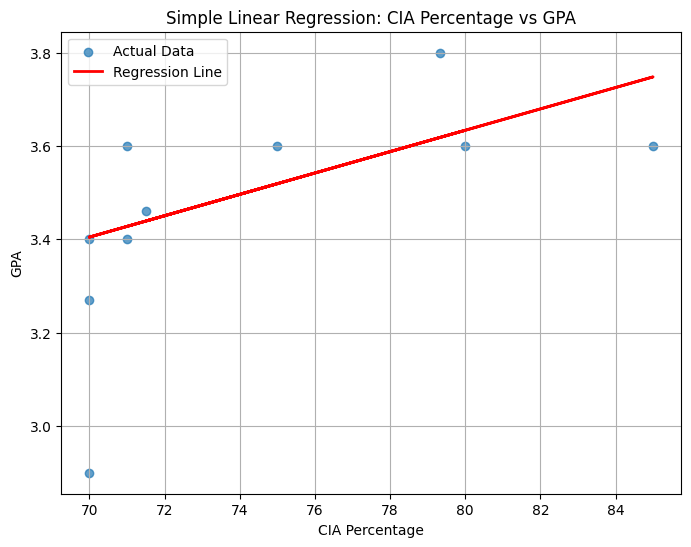

In [91]:
plt.figure(figsize=(8,6))

# Scatter plot
plt.scatter(
    X_test,
    y_test,
    alpha=0.7,
    label='Actual Data'
)

# Regression line
plt.plot(
    X_test,
    CIA_GPA_y_pred_sklearn,
    color='red',
    linewidth=2,
    label='Regression Line'
)

plt.title('Simple Linear Regression: CIA Percentage vs GPA')
plt.xlabel('CIA Percentage')
plt.ylabel('GPA')
plt.legend()
plt.grid(True)

plt.show()

**Independent Variable (X): Attendance Percentage**

**Dependent Variable (Y): GPA**

In [99]:
X = data[['MaxAttendanceTillLastSemester']]
y = data['LastSemesterGPA']

In [100]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [101]:
Attendance_GPA_sklearn_model = LinearRegression()

Attendance_GPA_sklearn_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [102]:
Attendance_GPA_sklearn_slope = Attendance_GPA_sklearn_model.coef_[0]
Attendance_GPA_sklearn_intercept = Attendance_GPA_sklearn_model.intercept_

print("Slope:", Attendance_GPA_sklearn_slope)
print("Intercept:", Attendance_GPA_sklearn_intercept)


Slope: 0.017863409101331218
Intercept: 1.802554264539831


In [103]:
Attendance_GPA_y_pred_sklearn = Attendance_GPA_sklearn_model.predict(X_test)

In [93]:
# Convert training data to NumPy arrays
x_train = X_train['LastSemesterCIA'].values
y_train_np = y_train.values

In [104]:
Attendance_GPA_r2_sklearn = r2_score(
    y_test,
    Attendance_GPA_y_pred_sklearn
)

Attendance_GPA_mae_sklearn = mean_absolute_error(
    y_test,
    Attendance_GPA_y_pred_sklearn
)

Attendance_GPA_rmse_sklearn = np.sqrt(
    mean_squared_error(
        y_test,
        Attendance_GPA_y_pred_sklearn
    )
)

print("R² Score :", Attendance_GPA_r2_sklearn)
print("MAE      :", Attendance_GPA_mae_sklearn)
print("RMSE     :", Attendance_GPA_rmse_sklearn)

R² Score : 0.28149584558966045
MAE      : 0.14261501279466232
RMSE     : 0.19893699336492426


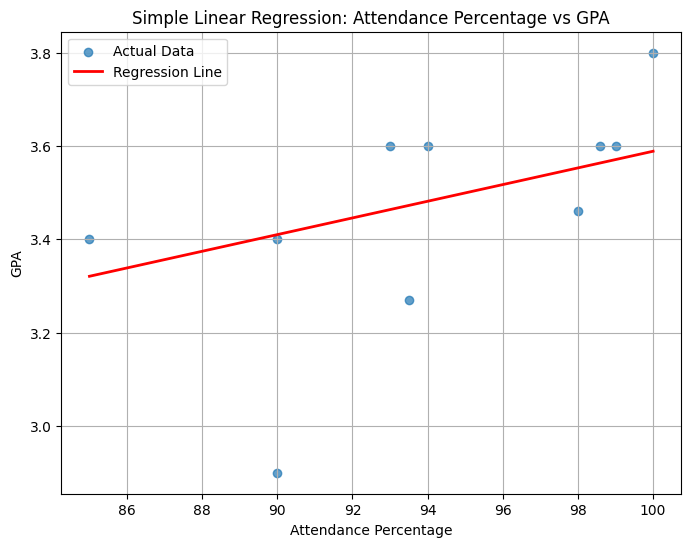

In [105]:
sorted_idx = np.argsort(
    X_test['MaxAttendanceTillLastSemester']
)

plt.figure(figsize=(8,6))

plt.scatter(
    X_test,
    y_test,
    alpha=0.7,
    label='Actual Data'
)

plt.plot(
    X_test.iloc[sorted_idx],
    Attendance_GPA_y_pred_sklearn[sorted_idx],
    color='red',
    linewidth=2,
    label='Regression Line'
)

plt.title('Simple Linear Regression: Attendance Percentage vs GPA')
plt.xlabel('Attendance Percentage')
plt.ylabel('GPA')
plt.legend()
plt.grid(True)

plt.show()

### Part C: Manual Computation using Ordinary Least Squares (OLS)
Using the same dataset, manually compute the regression line using the OLS formulas given below.

**Independent Variable (X): CIA Percentage**

**Dependent Variable (Y): GPA**

In [94]:
# Mean of X and Y
x_mean = np.mean(x_train)
y_mean = np.mean(y_train_np)

print("Mean of X:", x_mean)
print("Mean of Y:", y_mean)

Mean of X: 72.74425
Mean of Y: 3.4677499999999997


In [95]:
CIA_GPA_ols_slope = (
    np.sum((x_train - x_mean) * (y_train_np - y_mean))
    /
    np.sum((x_train - x_mean) ** 2)
)

print("Manual OLS Slope:", CIA_GPA_ols_slope)

Manual OLS Slope: 0.022886359853466723


In [96]:
CIA_GPA_ols_intercept = y_mean - (CIA_GPA_ols_slope * x_mean)

print("Manual OLS Intercept:", CIA_GPA_ols_intercept)

Manual OLS Intercept: 1.8028989172294532


In [97]:
CIA_GPA_y_pred_ols = (
    CIA_GPA_ols_slope * X_test['LastSemesterCIA']
    + CIA_GPA_ols_intercept
)

In [98]:
CIA_GPA_r2_ols = r2_score(y_test, CIA_GPA_y_pred_ols)
CIA_GPA_mae_ols = mean_absolute_error(y_test, CIA_GPA_y_pred_ols)
CIA_GPA_rmse_ols = np.sqrt(
    mean_squared_error(y_test, CIA_GPA_y_pred_ols)
)

print("Manual OLS Results")
print("------------------")
print("R² Score :", CIA_GPA_r2_ols)
print("MAE      :", CIA_GPA_mae_ols)
print("RMSE     :", CIA_GPA_rmse_ols)

Manual OLS Results
------------------
R² Score : 0.33439975035051006
MAE      : 0.13097561338005384
RMSE     : 0.19147304601677897


**Independent Variable (X): Attendance Percentage**

**Dependent Variable (Y): GPA**

In [106]:
x_train = X_train['MaxAttendanceTillLastSemester'].values
y_train_np = y_train.values

In [107]:
x_mean = np.mean(x_train)
y_mean = np.mean(y_train_np)

In [108]:
Attendance_GPA_ols_slope = (
    np.sum((x_train - x_mean) * (y_train_np - y_mean))
    /
    np.sum((x_train - x_mean) ** 2)
)

print("Manual Slope:", Attendance_GPA_ols_slope)

Manual Slope: 0.01786340910133122


In [109]:
Attendance_GPA_ols_intercept = (
    y_mean
    - Attendance_GPA_ols_slope * x_mean
)

print("Manual Intercept:", Attendance_GPA_ols_intercept)

Manual Intercept: 1.8025542645398305


In [110]:
Attendance_GPA_y_pred_ols = (
    Attendance_GPA_ols_slope
    * X_test['MaxAttendanceTillLastSemester']
    + Attendance_GPA_ols_intercept
)

In [111]:
Attendance_GPA_r2_ols = r2_score(
    y_test,
    Attendance_GPA_y_pred_ols
)

Attendance_GPA_mae_ols = mean_absolute_error(
    y_test,
    Attendance_GPA_y_pred_ols
)

Attendance_GPA_rmse_ols = np.sqrt(
    mean_squared_error(
        y_test,
        Attendance_GPA_y_pred_ols
    )
)

print("Manual OLS Results")
print("------------------")
print("R² Score :", Attendance_GPA_r2_ols)
print("MAE      :", Attendance_GPA_mae_ols)
print("RMSE     :", Attendance_GPA_rmse_ols)

Manual OLS Results
------------------
R² Score : 0.28149584558966
MAE      : 0.14261501279466246
RMSE     : 0.19893699336492432


In [119]:
CIA_GPA_comparison = pd.DataFrame({
    'Parameter': [
        'Slope',
        'Intercept',
        'R² Score',
        'MAE',
        'RMSE'
    ],
    'Scikit-learn': [
        CIA_GPA_sklearn_slope,
        CIA_GPA_sklearn_intercept,
        CIA_GPA_r2_sklearn,
        CIA_GPA_mae_sklearn,
        CIA_GPA_rmse_sklearn
    ],
    'Manual OLS': [
        CIA_GPA_ols_slope,
        CIA_GPA_ols_intercept,
        CIA_GPA_r2_ols,
        CIA_GPA_mae_ols,
        CIA_GPA_rmse_ols
    ]
})

CIA_GPA_comparison

,Parameter,Scikit-learn,Manual OLS
0,Slope,0.017863,0.022886
1,Intercept,1.802554,1.802899
2,R² Score,0.334400,0.334400
3,MAE,0.130976,0.130976
4,RMSE,0.191473,0.191473


In [120]:
Attendance_GPA_comparison = pd.DataFrame({
    'Parameter': [
        'Slope',
        'Intercept',
        'R² Score',
        'MAE',
        'RMSE'
    ],
    'Scikit-learn': [
        Attendance_GPA_sklearn_slope,
        Attendance_GPA_sklearn_intercept,
        Attendance_GPA_r2_sklearn,
        Attendance_GPA_mae_sklearn,
        Attendance_GPA_rmse_sklearn
    ],
    'Manual OLS': [
        Attendance_GPA_ols_slope,
        Attendance_GPA_ols_intercept,
        Attendance_GPA_r2_ols,
        Attendance_GPA_mae_ols,
        Attendance_GPA_rmse_ols
    ]
})

Attendance_GPA_comparison

,Parameter,Scikit-learn,Manual OLS
0,Slope,0.017863,0.017863
1,Intercept,1.802554,1.802554
2,R² Score,0.281496,0.281496
3,MAE,0.142615,0.142615
4,RMSE,0.198937,0.198937


### Parameter Saving using Pickle


In [123]:
weights = {

    "CIA_GPA": {
        "Slope": CIA_GPA_sklearn_slope,
        "Intercept": CIA_GPA_sklearn_intercept
    },

    "Attendance_GPA": {
        "Slope": Attendance_GPA_sklearn_slope,
        "Intercept": Attendance_GPA_sklearn_intercept
    }

}

with open("linear_regression_weights.pkl", "wb") as file:
    pickle.dump(weights, file)

print("Parameters saved successfully.")

Parameters saved successfully.


In [124]:
with open("linear_regression_weights.pkl", "rb") as file:
    loaded_weights = pickle.load(file)

print(loaded_weights)

{'CIA_GPA': {'Slope': np.float64(0.017863409101331218), 'Intercept': np.float64(1.802554264539831)}, 'Attendance_GPA': {'Slope': np.float64(0.017863409101331218), 'Intercept': np.float64(1.802554264539831)}}


In [126]:
loaded_slope = loaded_weights["Attendance_GPA"]["Slope"]
loaded_intercept = loaded_weights["Attendance_GPA"]["Intercept"]

Attendance_loaded_prediction = (
    loaded_slope * X_test['MaxAttendanceTillLastSemester']
    + loaded_intercept
)

Attendance_loaded_prediction.head()

14    3.410261
41    3.472783
32    3.481715
48    3.553168
18    3.463851
Name: MaxAttendanceTillLastSemester, dtype: float64